In [40]:
import cv2
import h5py
import yaml
import math
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

ROOT = Path.cwd()
DATA_DIR = ROOT / "svhn_data"
RAW_DIR = DATA_DIR / "raw"
YOLO_DIR = DATA_DIR / "yolo"
RUNS_DIR = ROOT / "runs_svhn"
MODELS_DIR = ROOT / "models"

YOLO_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT =", ROOT)
print("RAW_DIR =", RAW_DIR)

ROOT = c:\Users\krasn\Desktop\ML\itmo-cv-lab-5
RAW_DIR = c:\Users\krasn\Desktop\ML\itmo-cv-lab-5\svhn_data\raw


In [41]:
for split in ["train", "test"]:
    split_dir = RAW_DIR / split
    print(split, split_dir.exists(), (split_dir / "digitStruct.mat").exists(), len(list(split_dir.glob("*.png"))))

train True True 33402
test True True 13068


In [42]:
def read_name(f, ref):
    data = f[ref]
    return "".join(chr(int(x[0])) for x in data[:])

def read_bbox_attr(f, attr):
    if len(attr) > 1:
        values = []
        for i in range(len(attr)):
            ref = attr[i][0]
            values.append(float(f[ref][()][0][0]))
        return values
    return [float(attr[()][0][0])]

def parse_digit_struct(mat_path):
    result = []
    with h5py.File(mat_path, "r") as f:
        ds = f["digitStruct"]
        names = ds["name"]
        bboxes = ds["bbox"]

        for i in tqdm(range(len(names)), desc=f"Parsing {mat_path.parent.name}"):
            name_ref = names[i][0]
            bbox_ref = bboxes[i][0]

            filename = read_name(f, name_ref)
            bbox = f[bbox_ref]

            left = read_bbox_attr(f, bbox["left"])
            top = read_bbox_attr(f, bbox["top"])
            width = read_bbox_attr(f, bbox["width"])
            height = read_bbox_attr(f, bbox["height"])
            label = read_bbox_attr(f, bbox["label"])

            label = [0 if int(x) == 10 else int(x) for x in label]

            result.append({
                "filename": filename,
                "left": left,
                "top": top,
                "width": width,
                "height": height,
                "label": label
            })
    return result

In [43]:
def get_union_box(item, img_w, img_h):
    x1 = min(item["left"])
    y1 = min(item["top"])
    x2 = max([l + w for l, w in zip(item["left"], item["width"])])
    y2 = max([t + h for t, h in zip(item["top"], item["height"])])

    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(1, min(x2, img_w))
    y2 = max(1, min(y2, img_h))

    return x1, y1, x2, y2

def to_yolo_line(box, img_w, img_h, cls_id=0):
    x1, y1, x2, y2 = box
    xc = ((x1 + x2) / 2) / img_w
    yc = ((y1 + y2) / 2) / img_h
    bw = (x2 - x1) / img_w
    bh = (y2 - y1) / img_h
    return f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"

In [44]:
for part in ["train", "val"]:
    (YOLO_DIR / "images" / part).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / part).mkdir(parents=True, exist_ok=True)

print("YOLO folders ready")

YOLO folders ready


In [45]:
def convert_split(src_dir, dst_images_dir, dst_labels_dir, prefix=""):
    items = parse_digit_struct(src_dir / "digitStruct.mat")
    saved = 0

    for item in tqdm(items, desc=f"Converting {src_dir.name}"):
        img_path = src_dir / item["filename"]
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        h, w = img.shape[:2]
        box = get_union_box(item, w, h)
        x1, y1, x2, y2 = box

        if x2 <= x1 or y2 <= y1:
            continue

        new_name = f"{prefix}{item['filename']}"
        out_img = dst_images_dir / new_name
        out_lbl = dst_labels_dir / f"{Path(new_name).stem}.txt"

        shutil.copy2(img_path, out_img)
        out_lbl.write_text(to_yolo_line(box, w, h), encoding="utf-8")

        saved += 1

    return saved

In [46]:
train_saved = convert_split(
    RAW_DIR / "train",
    YOLO_DIR / "images" / "train",
    YOLO_DIR / "labels" / "train",
    prefix="train_"
)

# extra_saved = convert_split(
#     RAW_DIR / "extra",
#     YOLO_DIR / "images" / "train",
#     YOLO_DIR / "labels" / "train",
#     prefix="extra_"
# )

val_saved = convert_split(
    RAW_DIR / "test",
    YOLO_DIR / "images" / "val",
    YOLO_DIR / "labels" / "val",
    prefix="test_"
)

print("train saved =", train_saved)
# print("extra saved =", extra_saved)
print("val saved =", val_saved)

Converting test: 100%|██████████| 13068/13068 [00:40<00:00, 321.14it/s]

train saved = 33402
val saved = 13068


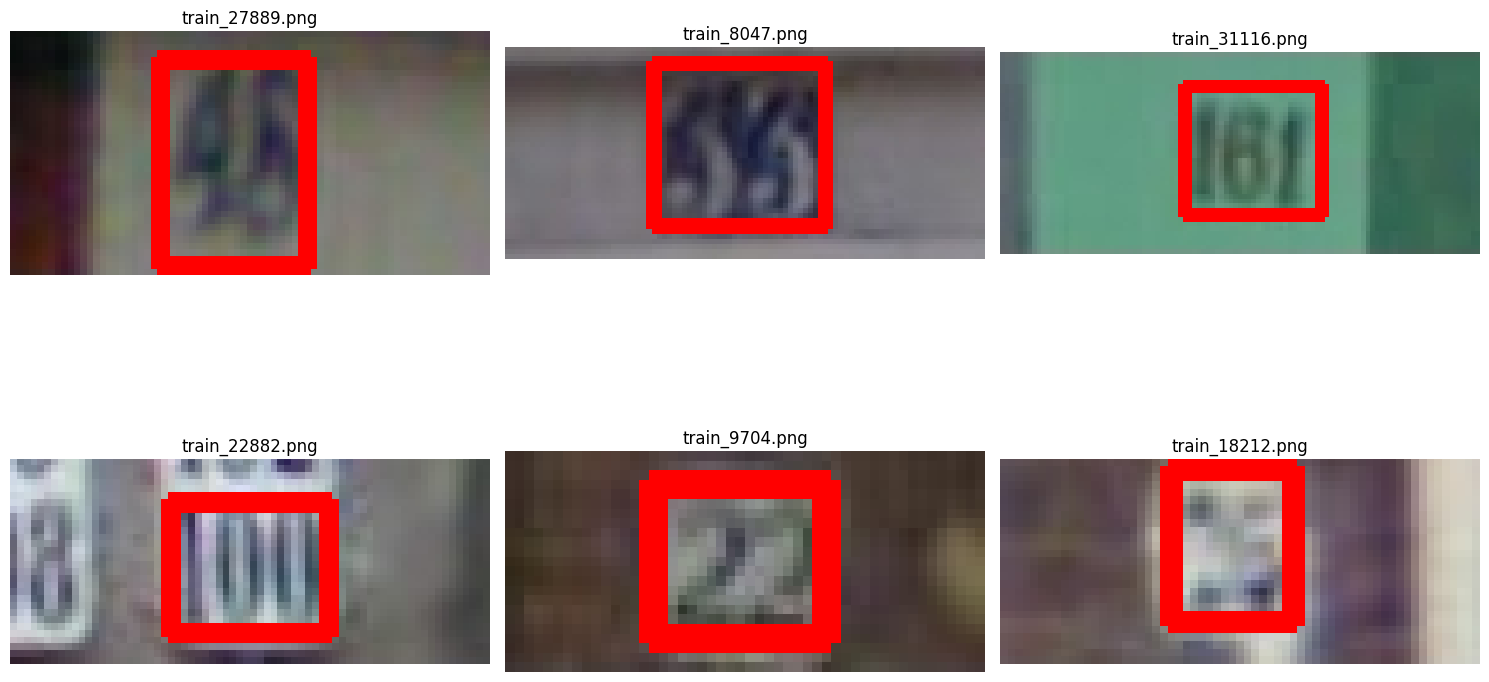

In [47]:
def show_random_samples(images_dir, labels_dir, n=6):
    image_paths = list(images_dir.glob("*.png"))
    sample = random.sample(image_paths, min(n, len(image_paths)))

    plt.figure(figsize=(15, 10))

    for i, img_path in enumerate(sample, 1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        label_path = labels_dir / f"{img_path.stem}.txt"
        line = label_path.read_text(encoding="utf-8").strip().split()
        _, xc, yc, bw, bh = map(float, line)

        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        plt.subplot(math.ceil(n / 3), 3, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)

    plt.tight_layout()
    plt.show()

show_random_samples(YOLO_DIR / "images" / "train", YOLO_DIR / "labels" / "train", n=6)

In [48]:
yaml_text = f"""
path: {YOLO_DIR}
train: images/train
val: images/val

names:
  0: number
""".strip()

yaml_path = YOLO_DIR / "svhn_number.yaml"
yaml_path.write_text(yaml_text, encoding="utf-8")

print(yaml_path.read_text(encoding="utf-8"))

path: c:\Users\krasn\Desktop\ML\itmo-cv-lab-5\svhn_data\yolo
train: images/train
val: images/val

names:
  0: number


In [49]:
model = YOLO("yolov8n.pt")
print("Model loaded")

Model loaded


In [50]:

train_results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project=str(RUNS_DIR),
    name="yolo_number",
    pretrained=True
)

New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.9.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3070, 8191MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\krasn\Desktop\ML\itmo-cv-lab-5\svhn_data\yolo\svhn_number.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937,

UnboundLocalError: local variable 'ax' referenced before assignment

In [51]:
best_model_path = RUNS_DIR / "yolo_number" / "weights" / "best.pt"
best_model = YOLO(str(best_model_path))
print(best_model_path)

c:\Users\krasn\Desktop\ML\itmo-cv-lab-5\runs_svhn\yolo_number\weights\best.pt


In [52]:
metrics = best_model.val(
    data=str(yaml_path),
    device=0
)
metrics

Ultralytics 8.4.32  Python-3.9.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3070, 8191MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.2 ms, read: 193.6350.4 MB/s, size: 32.9 KB)
val: Scanning C:\Users\krasn\Desktop\ML\itmo-cv-lab-5\svhn_data\yolo\labels\val.cache... 13068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13068/13068  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 817/817 8.6it/s 1:35<0.1sss
                   all      13068      13068      0.919      0.892      0.936      0.556
Speed: 1.2ms preprocess, 1.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\detect\val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002406E819340>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [54]:
precision = float(metrics.box.mp)
recall = float(metrics.box.mr)
map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)

print("Precision:", precision)
print("Recall:", recall)
print("mAP50:", map50)
print("mAP50-95:", map5095)

Precision: 0.9192609247221751
Recall: 0.892166393549275
mAP50: 0.9359915651623529
mAP50-95: 0.555900382643537


In [55]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - inter
    if union == 0:
        return 0.0
    return inter / union

def yolo_label_to_xyxy(label_path, img_w, img_h):
    parts = label_path.read_text(encoding="utf-8").strip().split()
    _, xc, yc, bw, bh = map(float, parts)

    x1 = (xc - bw / 2) * img_w
    y1 = (yc - bh / 2) * img_h
    x2 = (xc + bw / 2) * img_w
    y2 = (yc + bh / 2) * img_h

    return [x1, y1, x2, y2]

ious = []
val_paths = list((YOLO_DIR / "images" / "val").glob("*.png"))

for img_path in tqdm(val_paths[:2000], desc="IoU evaluation"):
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    h, w = img.shape[:2]
    gt_path = YOLO_DIR / "labels" / "val" / f"{img_path.stem}.txt"
    gt_box = yolo_label_to_xyxy(gt_path, w, h)

    result = best_model.predict(
        source=str(img_path),
        imgsz=640,
        conf=0.01,
        device=0,
        verbose=False
    )[0]

    if result.boxes is None or len(result.boxes) == 0:
        continue

    pred_boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()

    best_idx = int(np.argmax(confs))
    pred_box = pred_boxes[best_idx].tolist()

    iou = compute_iou(gt_box, pred_box)
    ious.append(iou)

mean_iou = float(np.mean(ious)) if ious else 0.0
print("Mean IoU:", mean_iou)
print("Evaluated images:", len(ious))

IoU evaluation: 100%|██████████| 2000/2000 [00:33<00:00, 60.61it/s]

Mean IoU: 0.7475163215291867
Evaluated images: 1996


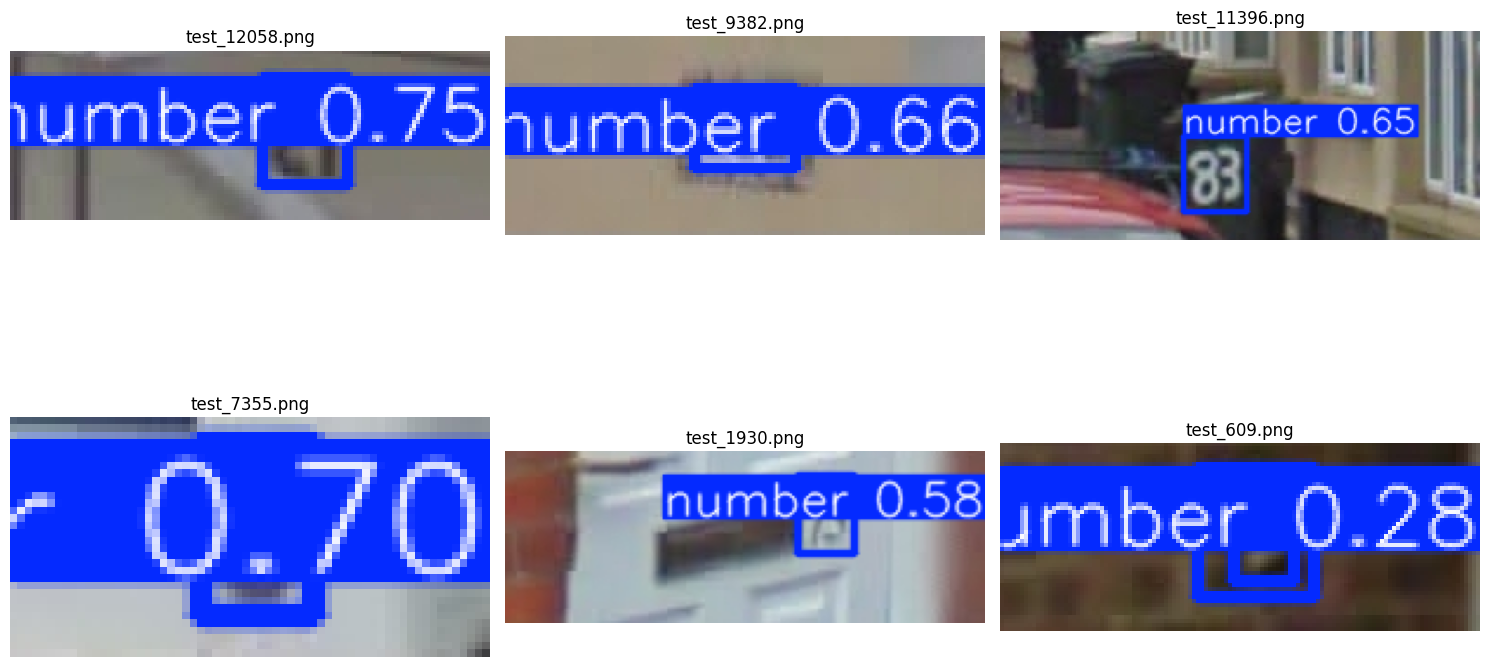

In [56]:
val_sample_paths = random.sample(list((YOLO_DIR / "images" / "val").glob("*.png")), 6)

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(val_sample_paths, 1):
    result = best_model.predict(
        source=str(img_path),
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )[0]

    plotted = result.plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i)
    plt.imshow(plotted)
    plt.axis("off")
    plt.title(img_path.name)

plt.tight_layout()
plt.show()

In [57]:
final_model_path = MODELS_DIR / "svhn_number_detector.pt"
shutil.copy2(best_model_path, final_model_path)
print("Saved to", final_model_path)

Saved to c:\Users\krasn\Desktop\ML\itmo-cv-lab-5\models\svhn_number_detector.pt


In [58]:
summary = {
    "Precision": precision,
    "Recall": recall,
    "mAP50": map50,
    "mAP50-95": map5095,
    "Mean IoU": mean_iou
}

print(summary)

{'Precision': 0.9192609247221751, 'Recall': 0.892166393549275, 'mAP50': 0.9359915651623529, 'mAP50-95': 0.555900382643537, 'Mean IoU': 0.7475163215291867}


In [63]:
MY_PHOTOS_DIR = ROOT / "my_photos"

photo_paths = []
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    photo_paths.extend(MY_PHOTOS_DIR.glob(ext))

photo_paths = sorted(photo_paths)

print("Found photos:", len(photo_paths))
for p in photo_paths:
    print(p.name)

Found photos: 9
1.png
2.png
3.png
4.png
5.png
6.png
7.png
8.png
9.png


In [64]:
PREDICT_DIR = ROOT / "runs_own_photos"

results = best_model.predict(
    source=str(MY_PHOTOS_DIR),
    imgsz=960,
    conf=0.25,
    device=0,
    save=True,
    project=str(PREDICT_DIR),
    name="predictions"
)

Results saved to C:\Users\krasn\Desktop\ML\itmo-cv-lab-5\runs_own_photos\predictions


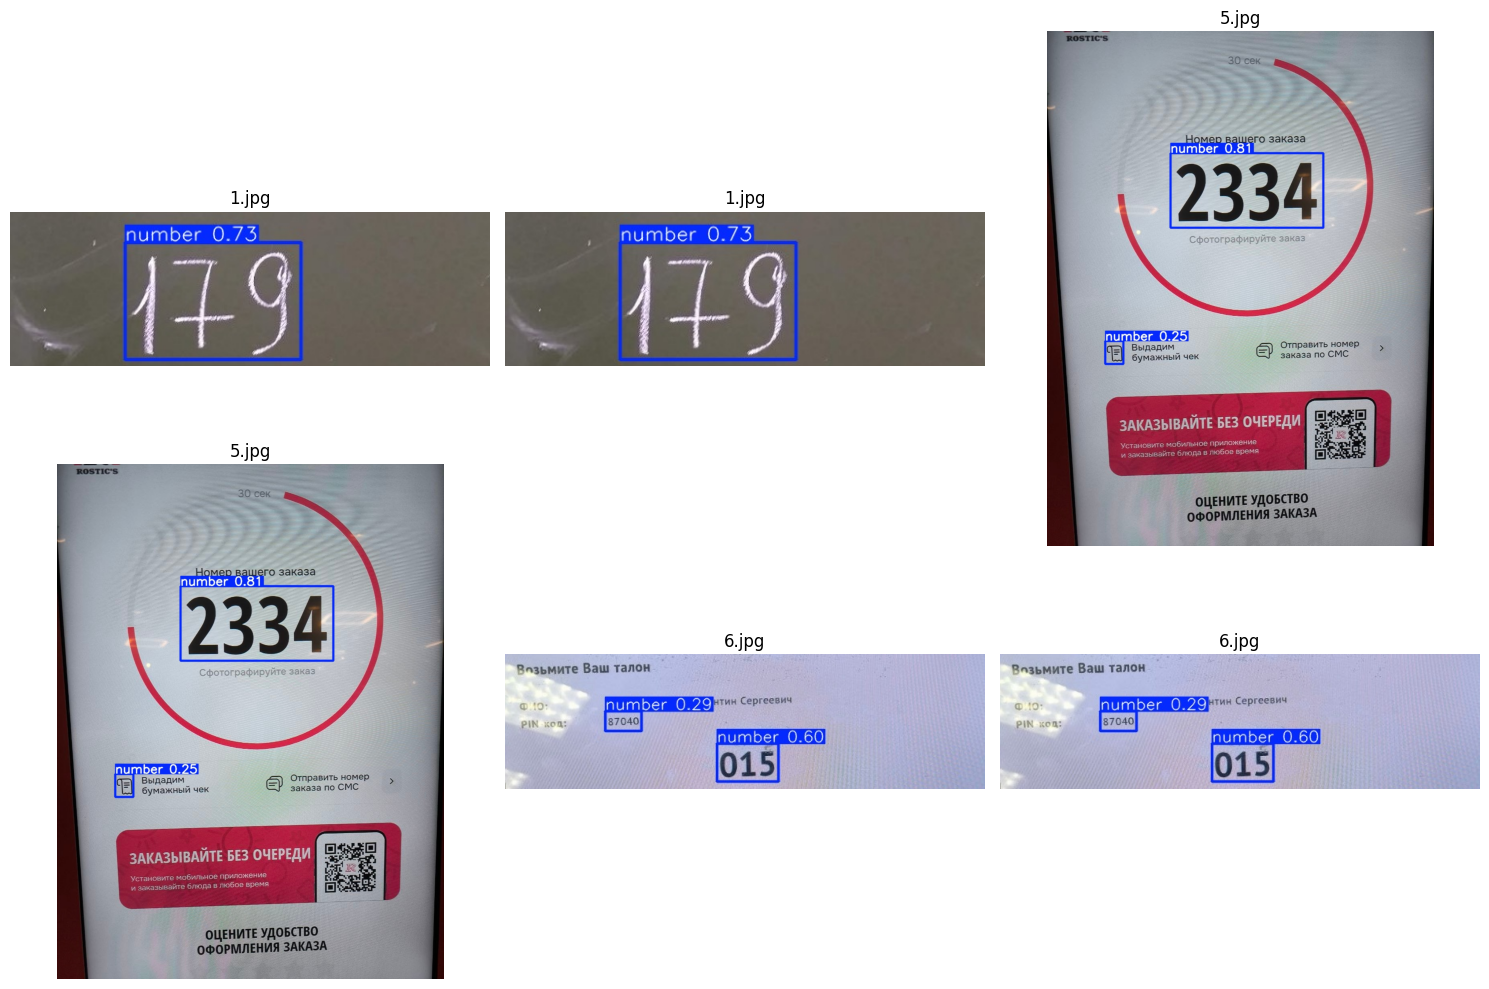

In [67]:
pred_dir = PREDICT_DIR / "predictions"

pred_images = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]:
    pred_images.extend(pred_dir.glob(ext))

pred_images = sorted(pred_images)

import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(pred_images[:6], 1):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)

plt.tight_layout()
plt.show()